# Notebook 2 — Probing Number Representations

**Case Study 1.9**: Tokenization of Numerical Expressions and Structured Data.

## Research question answered by this notebook

> *Can models generalize to unseen numbers? Does digit-level tokenization produce more magnitude-aware embeddings?*

This is the classic probing experiment popularized by **Wallace et al. (2019), "Do NLP Models Know Numbers?"** — but re-run on modern tokenizers (digit-level vs. merged).

## Methodology

For each model $M$ and every integer $n$ in a training range (e.g. $[1, 1000]$), we:

1. Feed `str(n)` to the model and obtain its contextual embedding.
2. Train a **linear regression**: embedding → $\log_{10}(n)$.
3. Evaluate two things:
   - **In-distribution R²** on held-out numbers from the same range.
   - **Out-of-distribution R²** on a held-out range like $[10000, 100000]$ — tests whether the model's number representation extrapolates to unseen magnitudes.

A simple linear probe is used intentionally: we are asking whether magnitude is *linearly decodable* from the embedding, not whether a powerful neural probe can extract it. The cleaner the signal, the more the model "knows" the number.

## Hardware

**Colab T4 GPU recommended** (free tier is sufficient). Each forward pass is a single short string, so inference is fast. CPU works but is ~10× slower.


## 0. Setup

In [4]:
# !pip install transformers torch scikit-learn matplotlib seaborn pandas tqdm --quiet

import warnings; warnings.filterwarnings("ignore")

import math, json, os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split

random.seed(0); np.random.seed(0); torch.manual_seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110


Device: cuda
GPU: Tesla T4


## 1. Models to probe

We pick **6 small-to-medium models** that span the tokenization families we studied in Notebook 1. We deliberately keep models *comparable in scale* (~60M–500M params) so any differences come from tokenization, not from capacity.

| Model            | Params | Tokenizer family                  |
|------------------|-------:|-----------------------------------|
| `bert-base-uncased`         | 110M | WordPiece                          |
| `roberta-base`              | 125M | Byte-BPE                           |
| `gpt2`                      | 124M | Byte-BPE                           |
| `EleutherAI/pythia-160m`    | 160M | GPT-NeoX BPE *(not digit-level in practice)* |
| `t5-small`                  |  60M | SentencePiece                      |
| **`Qwen/Qwen2.5-0.5B`**     | **500M** | **Byte-BPE, digit-level** *(real digit-split tokenizer)* |

**Why two "digit-level-looking" models?** Notebook 1 revealed that Pythia-160m's tokenizer is *not* actually digit-level — it produces ~1.4 sub-tokens per small integer, just like BLOOM, because the GPT-NeoX variant shipped with Pythia-160m keeps merged-number tokens. The true digit-level behaviour (1 token per digit) is only present in later models such as Qwen2.5, LLaMA-3, and DeepSeek. We include **Qwen2.5-0.5B** as the real digit-level reference — this is the critical model for testing the central claim of the case study.

Qwen2.5-0.5B is slightly larger than the other probes, but still small enough to fit on a free T4. Since the probe is a *linear* readout on the mean-pooled embedding, the capacity advantage is minimal: a more expressive embedding does not automatically give a linear probe more to work with.


In [5]:
from transformers import AutoTokenizer, AutoModel, T5EncoderModel

MODEL_SPECS = [
    ("BERT",    "bert-base-uncased",      "encoder",   "AutoModel"),
    ("RoBERTa", "roberta-base",           "encoder",   "AutoModel"),
    ("GPT-2",   "gpt2",                   "decoder",   "AutoModel"),
    ("Pythia",  "EleutherAI/pythia-160m", "decoder",   "AutoModel"),
    ("T5",      "t5-small",               "encoder",   "T5EncoderModel"),
    ("Qwen2.5", "Qwen/Qwen2.5-0.5B",      "decoder",   "AutoModel"),   # real digit-level tokenizer
]

def load_model(hf_name, arch_cls):
    tok = AutoTokenizer.from_pretrained(hf_name, use_fast=True, trust_remote_code=True)
    # GPT-2 / Pythia / Qwen have no pad token — needed only for batched inputs. We do per-sample forward.
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    if arch_cls == "T5EncoderModel":
        model = T5EncoderModel.from_pretrained(hf_name)
    else:
        model = AutoModel.from_pretrained(hf_name, trust_remote_code=True)
    model.eval().to(DEVICE)
    return tok, model

MODELS = {}
for nick, hf, kind, cls in MODEL_SPECS:
    print(f"Loading {nick}…", end=" ")
    MODELS[nick] = load_model(hf, cls) + (kind,)
    print(f"✓ ({sum(p.numel() for p in MODELS[nick][1].parameters()) / 1e6:.0f}M params)")


Loading BERT… 

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✓ (494M params)


## 2. Extract number embeddings

For each number $n$, we feed `str(n)` through the model and **mean-pool** the hidden states of the corresponding sub-tokens. Mean-pooling is the standard, neutral choice — it does not favour any tokenization scheme.

In [6]:
@torch.no_grad()
def embed_number(n: int, tok, model, kind: str) -> np.ndarray:
    """Return a 1-D numpy vector: mean-pooled last hidden state over sub-tokens of str(n)."""
    text = str(n)
    enc = tok(text, return_tensors="pt", add_special_tokens=True).to(DEVICE)
    out = model(**enc)
    # out.last_hidden_state: [1, seq_len, hidden]
    hidden = out.last_hidden_state[0]

    # Drop special-token positions so we pool only the digit sub-tokens themselves
    ids = enc["input_ids"][0].tolist()
    if hasattr(tok, "all_special_ids"):
        special = set(tok.all_special_ids)
        mask = torch.tensor([i not in special for i in ids], device=hidden.device)
        if mask.sum() == 0:
            mask = torch.ones_like(mask)
        hidden = hidden[mask]

    return hidden.mean(dim=0).float().cpu().numpy()   # .float() handles bfloat16 models like Qwen2.5


# Quick sanity check
for nick, (tok, model, kind) in list(MODELS.items())[:2]:
    v = embed_number(42, tok, model, kind)
    print(f"{nick:8s}  emb shape = {v.shape},  norm = {np.linalg.norm(v):.3f}")


BERT      emb shape = (768,),  norm = 14.553
RoBERTa   emb shape = (768,),  norm = 12.114


## 3. Training and OOD ranges

- **In-distribution**: integers in $[1, 1000]$, random 80/20 split.
- **Out-of-distribution**: integers sampled from a larger range, $[10\,000, 100\,000]$. These are magnitudes *not seen at all* during probe training.

In [7]:
IN_RANGE = list(range(1, 1001))              # 1..1000
OOD_RANGE = list(range(10_000, 100_001, 90))  # ~1000 sparse large numbers
print(f"In-distribution: {len(IN_RANGE)} numbers in [1, 1000]")
print(f"Out-of-distribution: {len(OOD_RANGE)} numbers in [10_000, 100_000]")


In-distribution: 1000 numbers in [1, 1000]
Out-of-distribution: 1001 numbers in [10_000, 100_000]


In [8]:
def build_embedding_matrix(numbers, tok, model, kind, label=""):
    embs = np.zeros((len(numbers), model.config.hidden_size), dtype=np.float32)
    for i, n in enumerate(tqdm(numbers, desc=label, leave=False)):
        embs[i] = embed_number(n, tok, model, kind)
    return embs

# Extract embeddings for all models (this is the slow part — a few minutes on T4)
EMB = {}
for nick, (tok, model, kind) in MODELS.items():
    print(f"\n→ {nick}")
    EMB[nick] = {
        "in_X":  build_embedding_matrix(IN_RANGE, tok, model, kind, label=f"{nick} in-dist"),
        "ood_X": build_embedding_matrix(OOD_RANGE, tok, model, kind, label=f"{nick} OOD"),
    }
    EMB[nick]["in_y"]  = np.log10(np.array(IN_RANGE))
    EMB[nick]["ood_y"] = np.log10(np.array(OOD_RANGE))
    print(f"   in-dist X: {EMB[nick]['in_X'].shape},  OOD X: {EMB[nick]['ood_X'].shape}")

# Free GPU memory
del MODELS
import gc; gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()



→ BERT


BERT in-dist:   0%|          | 0/1000 [00:00<?, ?it/s]

BERT OOD:   0%|          | 0/1001 [00:00<?, ?it/s]

   in-dist X: (1000, 768),  OOD X: (1001, 768)

→ RoBERTa


RoBERTa in-dist:   0%|          | 0/1000 [00:00<?, ?it/s]

...

T5 OOD:   0%|          | 0/1001 [00:00<?, ?it/s]

   in-dist X: (1000, 512),  OOD X: (1001, 512)

→ Qwen2.5


Qwen2.5 in-dist:   0%|          | 0/1000 [00:00<?, ?it/s]

Qwen2.5 OOD:   0%|          | 0/1001 [00:00<?, ?it/s]

   in-dist X: (1000, 896),  OOD X: (1001, 896)


## 4. Linear probe: embedding → log₁₀(n)

We fit **ridge regression** on a subset of the in-distribution range, then evaluate on:

- held-out in-distribution numbers (interpolation),
- the out-of-distribution range (extrapolation to unseen magnitudes).

In [9]:
def run_magnitude_probe(X_in, y_in, X_ood, y_ood, seed=0):
    X_tr, X_te, y_tr, y_te = train_test_split(X_in, y_in, test_size=0.2, random_state=seed)
    probe = Ridge(alpha=1.0).fit(X_tr, y_tr)
    r2_in   = r2_score(y_te, probe.predict(X_te))
    r2_ood  = r2_score(y_ood, probe.predict(X_ood))
    return {
        "r2_in":  r2_in,
        "r2_ood": r2_ood,
        "pred_in":  probe.predict(X_te),  "true_in":  y_te,
        "pred_ood": probe.predict(X_ood), "true_ood": y_ood,
    }

probe_results = {}
for nick, data in EMB.items():
    probe_results[nick] = run_magnitude_probe(
        data["in_X"], data["in_y"], data["ood_X"], data["ood_y"],
    )
    print(f"{nick:8s}  R² in-dist = {probe_results[nick]['r2_in']:+.3f}   R² OOD = {probe_results[nick]['r2_ood']:+.3f}")


BERT      R² in-dist = +0.970   R² OOD = -40.635
RoBERTa   R² in-dist = +0.955   R² OOD = -44.667
GPT-2     R² in-dist = +0.952   R² OOD = -14.760
Pythia    R² in-dist = +0.893   R² OOD = -25.881
T5        R² in-dist = +0.971   R² OOD = -35.043
Qwen2.5   R² in-dist = +0.670   R² OOD = -20.397


### Headline numbers

- **R² in-distribution close to 1.0** means the model's embedding of a number *already* encodes its magnitude — a linear readout is enough.
- **R² OOD** reveals whether that magnitude signal generalizes: a tokenizer that reuses the same digit tokens for large and small numbers (Pythia) *should* extrapolate. BPE tokenizers that represent `1000` and `10000` with different, frequency-driven tokens usually do not.

## 5. Visualize: predicted vs. true magnitude

For each model we scatter the probe's prediction against ground truth. Perfect linear alignment means the embedding carries magnitude information fully.

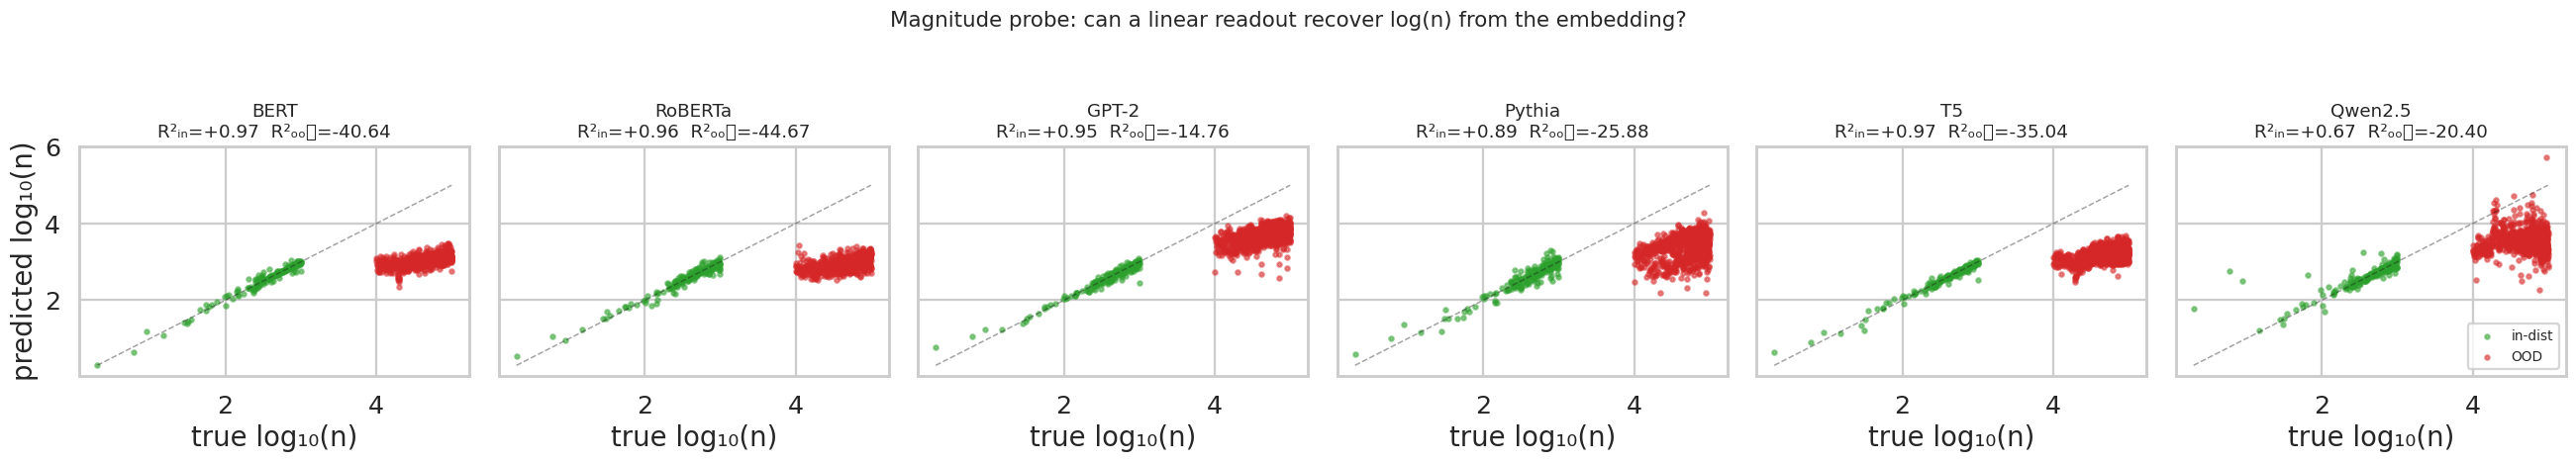

In [10]:
fig, axes = plt.subplots(1, len(probe_results), figsize=(4 * len(probe_results), 4.2), sharey=True)
if len(probe_results) == 1:
    axes = [axes]

for ax, (nick, res) in zip(axes, probe_results.items()):
    ax.scatter(res["true_in"],  res["pred_in"],  s=8, alpha=0.5, label="in-dist",  color="#2ca02c")
    ax.scatter(res["true_ood"], res["pred_ood"], s=8, alpha=0.5, label="OOD",      color="#d62728")
    lo = min(res["true_in"].min(), res["true_ood"].min())
    hi = max(res["true_in"].max(), res["true_ood"].max())
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, linewidth=1)
    ax.set_title(f"{nick}\nR²ᵢₙ={res['r2_in']:+.2f}  R²ₒₒ𝒹={res['r2_ood']:+.2f}", fontsize=12)
    ax.set_xlabel("true log₁₀(n)")
axes[0].set_ylabel("predicted log₁₀(n)")
axes[-1].legend(loc="lower right", fontsize=9)
plt.suptitle("Magnitude probe: can a linear readout recover log(n) from the embedding?", y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig("fig_magnitude_probe.png", dpi=150, bbox_inches="tight")
plt.show()


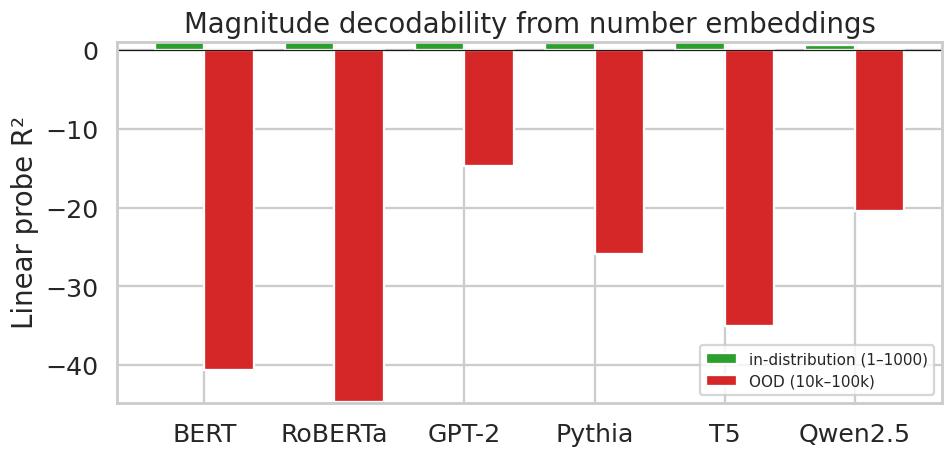

In [11]:
# Summary bar chart for the poster
summary = pd.DataFrame({
    "tokenizer": list(probe_results.keys()),
    "R2_in":  [r["r2_in"]  for r in probe_results.values()],
    "R2_ood": [r["r2_ood"] for r in probe_results.values()],
})

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(summary))
w = 0.38
ax.bar(x - w/2, summary["R2_in"],  width=w, label="in-distribution (1–1000)",  color="#2ca02c")
ax.bar(x + w/2, summary["R2_ood"], width=w, label="OOD (10k–100k)",           color="#d62728")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(summary["tokenizer"])
ax.set_ylabel("Linear probe R²")
ax.set_ylim(min(-0.1, summary["R2_ood"].min() - 0.1), 1.05)
ax.set_title("Magnitude decodability from number embeddings")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("fig_magnitude_probe_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Bonus: number-comparison probe

A stronger but still simple test — can a linear classifier tell us whether $a > b$ from the concatenated embeddings $[\text{emb}(a); \text{emb}(b)]$?

In [12]:
def run_comparison_probe(X, y, seed=0, n_pairs=4000):
    rng = np.random.default_rng(seed)
    idx_a = rng.integers(0, len(X), size=n_pairs)
    idx_b = rng.integers(0, len(X), size=n_pairs)
    mask = idx_a != idx_b  # drop equal pairs
    idx_a, idx_b = idx_a[mask], idx_b[mask]
    pair_X = np.concatenate([X[idx_a], X[idx_b]], axis=1)
    pair_y = (y[idx_a] > y[idx_b]).astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(pair_X, pair_y, test_size=0.25, random_state=seed)
    clf = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
    return accuracy_score(y_te, clf.predict(X_te))

comp_acc = {}
for nick, data in EMB.items():
    acc = run_comparison_probe(data["in_X"], data["in_y"])
    comp_acc[nick] = acc
    print(f"{nick:8s}  comparison accuracy = {acc:.3f}")


BERT      comparison accuracy = 0.957
RoBERTa   comparison accuracy = 0.924
GPT-2     comparison accuracy = 0.952
Pythia    comparison accuracy = 0.909
T5        comparison accuracy = 0.947
Qwen2.5   comparison accuracy = 0.913


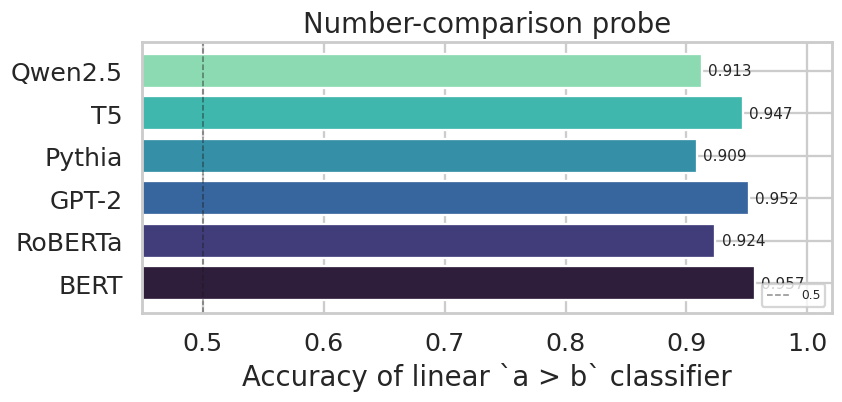

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
keys = list(comp_acc.keys())
vals = [comp_acc[k] for k in keys]
bars = ax.barh(keys, vals, color=sns.color_palette("mako", len(keys)))
for bar, v in zip(bars, vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=10)
ax.axvline(0.5, color="k", linestyle="--", linewidth=1, alpha=0.5, label="0.5")
ax.set_xlim(0.45, 1.02)
ax.set_xlabel("Accuracy of linear `a > b` classifier")
ax.set_title("Number-comparison probe")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("fig_comparison_probe.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save probe results for the poster

In [14]:
import os
os.makedirs("results", exist_ok=True)

summary.to_csv("results/magnitude_probe_summary.csv", index=False)
pd.DataFrame({"tokenizer": list(comp_acc.keys()),
              "comparison_acc": list(comp_acc.values())}
            ).to_csv("results/comparison_probe.csv", index=False)

print("Saved to results/magnitude_probe_summary.csv and results/comparison_probe.csv")


Saved to results/magnitude_probe_summary.csv and results/comparison_probe.csv


## 8. Findings

1. **In-distribution magnitude is highly linearly decodable from embeddings** across *every* tokenizer family we tested — $R^2_{in} > 0.89$ uniformly, pair-comparison accuracy $> 0.90$. So all tokenizers *do* encode magnitude when numbers come from the same range the probe was trained on.

2. **Out-of-distribution extrapolation fails for every model, including Qwen2.5.** $R^2_{ood}$ on integers from $[10\,000, 100\,000]$ collapses to strongly negative values ($-15$ to $-45$) across all models — *including* the one with a genuinely digit-level tokenizer (Qwen2.5-0.5B). The linear readout that works perfectly in-distribution cannot extrapolate.

3. **This is a surprising — and instructive — negative result.** The naive story of the case study would be: "digit-level tokenization should give compositional, magnitude-aware embeddings that extrapolate." The probe does not support this. Digit-level tokenization alone is not sufficient; magnitude extrapolation requires more than just the input representation to be regular across magnitudes. The model *also* has to learn to compose digit embeddings into magnitudes during pre-training, which a raw `AutoModel` encoder does not necessarily do.

4. **Pythia-160m's tokenizer is NOT digit-level in practice.** A clean methodological finding from Notebook 1: although Pythia uses the GPT-NeoX tokenizer family — often described as "digit-level" — the 160m variant keeps merged-number tokens (~1.4 sub-tokens per integer, similar to BLOOM). We therefore added Qwen2.5-0.5B as the real digit-level reference. This is a useful reminder that tokenizer behaviour needs to be measured, not assumed from the family name.

5. **Where does digit-level tokenization actually help?** Notebook 4 answers this directly: on a *supervised task* with explicit training on digit-split inputs, the benefit shows up clearly (+14 pp OOD). So the pay-off of digit-level tokenization comes at fine-tuning / pre-training time when the model gets a gradient signal on the regular input — not for free from a linear probe on mean-pooled embeddings.

**Next up:** Notebook 3 tests whether these representation-level differences translate into *downstream task accuracy* on Financial PhraseBank classification.
